In [1]:
# Step 1: Import Necessary Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [8]:
# Step 2: Load the Training Dataset

In [5]:
data = pd.read_csv(r"/content/drive/MyDrive/GOOGLE STOCK PRICE PREDICTION using RNN & LSTM/Data/Google_Stock_Price_Train.csv")

In [6]:
# Step 3: Inspect Dataset Structure and Summary

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [10]:
# Step 4 : Identify Missing Values in Each Column

In [11]:
# Check for missing values in each column of the DataFrame
# This helps in understanding the completeness of the dataset
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [12]:
# Step 5 : Generate Descriptive Statistics of the Dataset

In [13]:
data.describe()

,Open,High,Low
count,1258.000000,1258.000000,1258.000000
mean,533.709833,537.880223,529.007409
std,151.904442,153.008811,150.552807
min,279.120000,281.210000,277.220000
25%,404.115000,406.765000,401.765000
50%,537.470000,540.750000,532.990000
75%,654.922500,662.587500,644.800000
max,816.680000,816.680000,805.140000


In [15]:
# Step 6 : Clean and Convert Numeric Columns, Then Compute Correlation Matrix

In [16]:
# Clean and Convert Numeric Columns
# Iterate over specific columns to remove commas and convert to float
for column in ['Open', 'High', 'Low', 'Close', 'Volume']:  # Add other numeric columns as needed


# Check if the column type is object (string) before applying str.replace
  if data[column].dtype == object:
    data[column] = data[column].str.replace(',', '').astype(float)


# Select Only Numeric Columns
# Filter the DataFrame to include only numeric columns
numeric_data = data.select_dtypes(include=np.number)


# Compute Correlation Matrix
# Calculate the pairwise correlation of numeric columns, excluding NA/null values
correlation_matrix = numeric_data.corr()


# Display Correlation Matrix
# Print or visualize the correlation matrix as needed
print(correlation_matrix)


            Open      High       Low     Close    Volume
Open    1.000000  0.999692  0.999498  0.125832 -0.530506
High    0.999692  1.000000  0.999480  0.124351 -0.526936
Low     0.999498  0.999480  1.000000  0.129001 -0.538273
Close   0.125832  0.124351  0.129001  1.000000  0.192357
Volume -0.530506 -0.526936 -0.538273  0.192357  1.000000


In [ ]:
# Step 7 : Visualize Correlation Matrix Using Heatmap

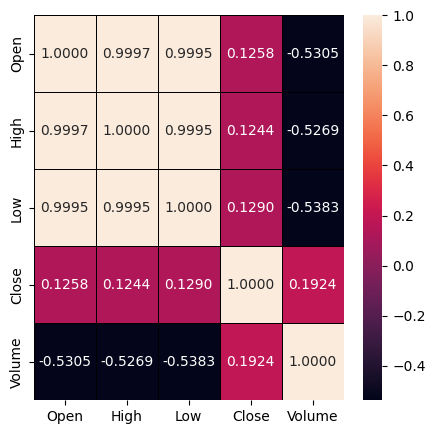

In [18]:
# Create a figure and axis for the heatmap
f, ax = plt.subplots(figsize=(5, 5))

# Drop the 'Date' column to focus on numerical data for correlation analysis
# Generate and display the correlation matrix using Seaborn's heatmap function
sns.heatmap(
    data.drop(columns=['Date']).corr(),      # Compute correlation matrix
    annot=True,                               # Annotate each cell with the numeric value
    linewidths=0.5,                           # Set width of lines that divide cells
    linecolor="black",                        # Set color of lines dividing cells
    fmt=".4f",                                 # Format annotations to 4 decimal places
    ax=ax                                      # Specify the axis to plot on
)
# Display the heatmap
plt.show()

In [19]:
# Step 8 : Retrieve and Review Dataset Column Names

In [20]:
# Retrieve and display the column names of the DataFrame
print("Dataset Columns:")
print(data.columns)

Dataset Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [23]:
# Step 9 : Extract 'Open' Column Values as a NumPy Array

In [21]:
# Extract the 'Open' column values and convert them into a NumPy array
# This array will be used as input features for the model
data_set = data.loc[:, ["Open"]].values

In [22]:
# Step 10: Split Dataset into Training and Testing Sets

In [24]:
train=data_set[:len(data_set)-50]
test=data_set[len(train):]
train.reshape(train.shape[0],1)
train.shape

(1208, 1)

In [25]:
# Step 11: Split the Dataset into Training and Testing Sets

In [26]:
# Determine the size of the training set (e.g., 80% of the data)
train_size = int(len(data_set) * 0.8)
# Split the dataset into training and testing sets
train = data_set[:train_size]
test = data_set[train_size:]

In [28]:
# Step 12: Reshape Training Data for LSTM Input

In [27]:
# Reshape the training data to match LSTM input requirements
# LSTM expects input in the form of [samples, time steps, features]
train = train.reshape((train.shape[0], 1))

In [29]:
# Step 13: Normalize the Training Data Using MinMaxScaler

In [30]:
# Import the MinMaxScaler from scikit-learn
from sklearn.preprocessing import MinMaxScaler
# Initialize the scaler with the desired feature range
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit the scaler on the training data and transform it
train_scaled = scaler.fit_transform(train)

In [ ]:
# Step 14: Visualize the Scaled Training Data

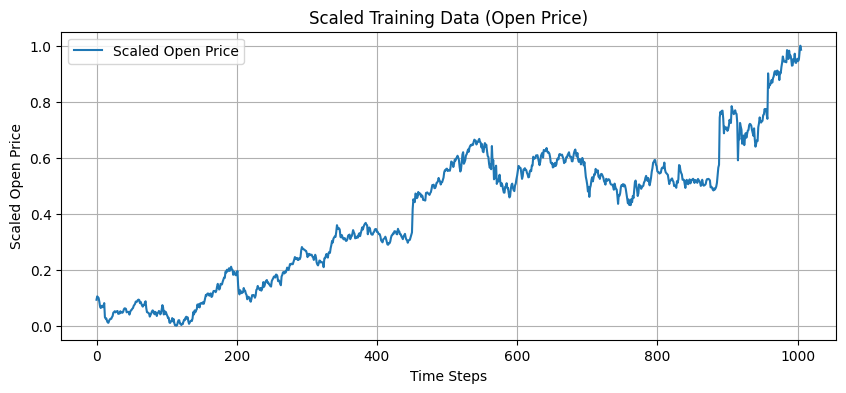

In [31]:
# Plot the scaled training data to visualize the normalized 'Open' prices
plt.figure(figsize=(10, 4))  # Set the figure size for better readability
plt.plot(train_scaled, label='Scaled Open Price')
plt.title('Scaled Training Data (Open Price)')
plt.xlabel('Time Steps')
plt.ylabel('Scaled Open Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 15 : Create Input Sequences and Targets for LSTM Training

In [33]:
# Initialize lists to hold input sequences (X) and corresponding targets (Y)
X_train = []
Y_train = []
# Define the number of time steps (sequence length)
timesteps = 10  # Adjust as needed, ensuring it's less than len(train_scaled)
# Loop to create sequences and corresponding targets
for i in range(timesteps, len(train_scaled)):
  X_train.append(train_scaled[i - timesteps:i, 0])  # Sequence of 'timesteps' length
  Y_train.append(train_scaled[i, 0])  # Target value following the sequence
# Convert lists to NumPy arrays
X_train = np.array(X_train)
Y_train = np.array(Y_train)
# Reshape X_train to be 3D as required for LSTM input: [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
# Inspect the Shape of the Training Data
# Display the shape of the training data
X_train.shape
X_train
# Understand the Role of y_train in Supervised Learning
Y_train

array([6.63745276e-02, 8.07670660e-02, 3.02323712e-02, 2.57095763e-02,
       2.60311972e-02, 1.72067219e-02, 1.16587602e-02, 1.04526815e-02,
       1.77494573e-02, 2.26943797e-02, 2.46442068e-02, 2.45638016e-02,
       3.03730803e-02, 3.47149634e-02, 4.68762563e-02, 4.83637533e-02,
       5.17608748e-02, 4.76200048e-02, 5.02331752e-02, 5.12784434e-02,
       5.26654338e-02, 4.25343732e-02, 4.47053148e-02, 4.35997427e-02,
       5.17005709e-02, 4.67355472e-02, 4.70772694e-02, 4.63134196e-02,
       4.97306424e-02, 5.83340034e-02, 6.20125432e-02, 6.17512262e-02,
       6.01833240e-02, 4.77808153e-02, 4.87858808e-02, 4.97708451e-02,
       4.76803088e-02, 3.97201898e-02, 4.84843612e-02, 5.47358688e-02,
       5.63439736e-02, 6.06456541e-02, 6.28768996e-02, 7.06762081e-02,
       7.43748492e-02, 7.82745035e-02, 8.63753317e-02, 8.47873281e-02,
       8.68175605e-02, 9.18227868e-02, 9.32298786e-02, 9.15413685e-02,
       8.05459516e-02, 8.51893543e-02, 7.82141996e-02, 7.20028946e-02,
      

In [ ]:
# Step 16 : Build and Train the Recurrent Neural Network (RNN) Model

In [34]:
#  Import necessary libraries
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Dropout
# Initialize the RNN model
regressor = Sequential()
# Add the first RNN layer with 50 units, 'tanh' activation, and dropout regularization
regressor.add(SimpleRNN(units=50, activation='tanh', return_sequences=True,
input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))
# Add the second RNN layer with 50 units and dropout regularization
regressor.add(SimpleRNN(units=50, activation='tanh', return_sequences=True))
regressor.add(Dropout(0.2))
# Add the third RNN layer with 50 units and dropout regularization
regressor.add(SimpleRNN(units=50, activation='tanh', return_sequences=True))
regressor.add(Dropout(0.2))
# Add the fourth RNN layer with 50 units and dropout regularization
regressor.add(SimpleRNN(units=50))
regressor.add(Dropout(0.2))
# Add the output layer with a single unit
regressor.add(Dense(units=1))
# Compile the RNN model using the Adam optimizer and mean squared error loss function
regressor.compile(optimizer='adam', loss='mean_squared_error')
# Train the RNN model on the training data for 100 epochs with a batch size of 32
regressor.fit(X_train, Y_train, epochs=100, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.3034
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1745
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1495
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0928
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0590
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0567
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0472
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0453
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0321
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0347
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0306
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0245
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0185
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0195
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

In [36]:
# Step 17 : Prepare and Scale Input Data for Prediction

In [37]:
# Extract the last 'timesteps' number of records from the original dataset
inputs = data_set[len(data_set) - len(test) - timesteps:]
# Apply the same scaling transformation used on the training data
inputs = scaler.transform(inputs)

In [38]:
# Step 18 : Prepare Test Data and Generate Predictions Using the Trained RNN Model

In [39]:
# Initialize a list to hold the test sequences
X_test = []
# Create sequences of 'timesteps' length from the input data
for i in range(timesteps, inputs.shape[0]):
  X_test.append(inputs[i - timesteps:i, 0])
# Convert the list to a NumPy array
X_test_rnn = np.array(X_test)
# Reshape the data to match the RNN input shape: (samples, timesteps, features)
X_test_rnn = np.reshape(X_test_rnn, (X_test_rnn.shape[0], X_test_rnn.shape[1], 1))
# Use the trained RNN model to make predictions on the test data
predicted_stock_price = regressor.predict(X_test_rnn)
# Inverse transform the predicted values to their original scale
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step


In [41]:
# Step 19 : Visualize Actual vs. Predicted Stock Prices

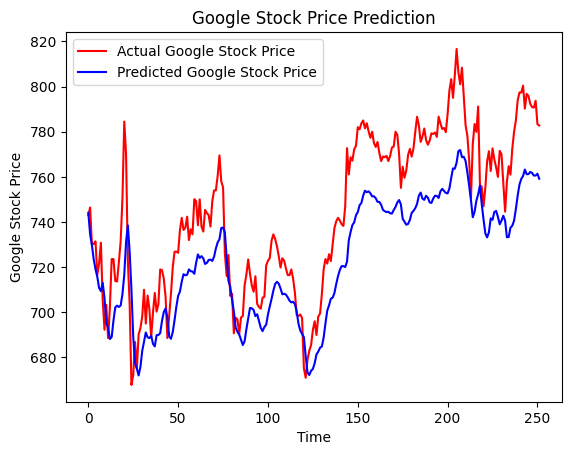

In [42]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt
# Plot the actual stock prices in red
plt.plot(test, color='red', label='Actual Google Stock Price')
# Plot the predicted stock prices in blue
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
# Add title and labels to the plot
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
# Display the legend
plt.legend()
# Show the plot
plt.show()

In [44]:
# Step 20 : Reshape Training Data for RNN Input

In [43]:
# Reshape X_train to match the RNN input shape: (samples, timesteps, features)
trainX = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))

In [45]:
# Step 21 : Import Essential Libraries for Building and Evaluating the LSTM Model

In [46]:
# Import mathematical functions
import math
# Import Keras modules for building the model
from keras.models import Sequential
from keras.layers import Dense, LSTM
# Import scikit-learn modules for data preprocessing and evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


In [48]:
# Step 22 : Build and Train the LSTM Model for Stock Price Prediction

In [47]:
# Initialize the LSTM model
model = Sequential()
# Add an LSTM layer with 10 units; input_shape is (timesteps, features)
model.add(LSTM(10, input_shape=(1, timesteps)))
# Add a Dense output layer with 1 unit for regression output
model.add(Dense(1))
# Compile the model using mean squared error loss and Adam optimizer
model.compile(loss='mean_squared_error', optimizer='adam')
# Train the model on the training data
model.fit(trainX, Y_train, epochs=50, batch_size=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0541
Epoch 2/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.8341e-04
Epoch 3/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.3674e-04
Epoch 4/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.5144e-04
Epoch 5/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.5712e-04
Epoch 6/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 4.4121e-04
Epoch 7/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.5468e-04
Epoch 8/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.8404e-04
Epoch 9/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.6292e-04
Epoch 10/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.8207e-04
Epoch 11/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.0618e-04
Epoch 12/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.1687e-04
Epoch 13/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.3871e-04
Epoch 14/50
996/996 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.1357e-04
Epoch

In [49]:
# Step 23: Prepare Test Data and Generate Predictions Using the LSTM Model

In [50]:
# Convert the test sequences into a NumPy array
testX = np.array(X_test)
# Reshape test data to match LSTM input shape: (samples, timesteps, features)
testX = testX.reshape(testX.shape[0], 1, testX.shape[1])
# Generate predictions using the trained LSTM model
predict_lstm = model.predict(testX)
# Inverse transform the predictions to return them to their original scale
predict_lstm = scaler.inverse_transform(predict_lstm)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [51]:
# Step 24 : Visualize Actual vs. Predicted Stock Prices Using the LSTM Model

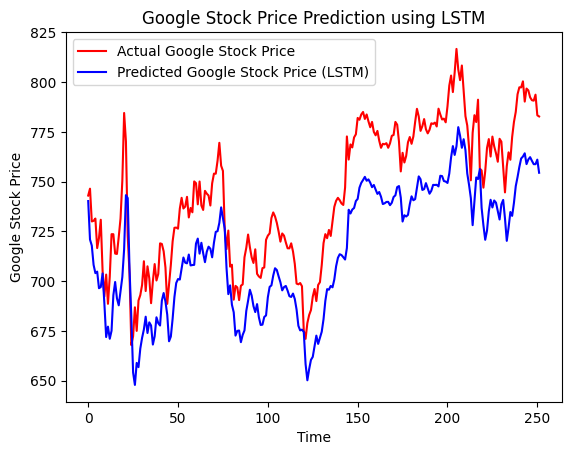

In [52]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt
# Plot the actual stock prices in red
plt.plot(test, color='red', label='Actual Google Stock Price')
# Plot the predicted stock prices from the LSTM model in blue
plt.plot(predict_lstm, color='blue', label='Predicted Google Stock Price (LSTM)')
# Add title and labels to the plot
plt.title('Google Stock Price Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
# Display the legend
plt.legend()
# Show the plot
plt.show()